# TerraNova FEMA Disaster Cost Modelling & Evaluation

## Purpose

The purpose of this modelling stage is to train machine learning models that can predict the expected FEMA disaster recovery cost.


For this FEMA project, the question becomes:

> Given a disaster's declaration details, public assistance activity, demand, severity and frequency, how much recovery cost should FEMA expect?

## Business Solution

The model will estimate disaster recovery cost using engineered features such as:

- disaster duration
- declaration delay
- state
- incident type
- project amount
- federal share obligated
- project count
- demand registrations
- DSF score

Because disaster cost is usually highly skewed, we use a log-transformed target:

`log_total_obligated`

This helps the model learn better patterns from very large and very small disaster costs.

## Models Used

1. Linear Regression  
   Simple, fast, interpretable baseline model.

2. Random Forest Regressor  
   Handles non-linear relationships and feature interactions.

3. XGBoost Regressor  
   Advanced boosting model, often strong for tabular data.

In [74]:

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")

os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(
    os.path.join(DATA_PROCESSED, "features_fema.csv")
)

df.head()

,disasternumber,fydeclared,designatedarea,disaster_duration_days,declaration_delay_days,declaration_year,declaration_month,declaration_quarter,pa_project_count,pa_project_amount_total,...,incidenttype_Toxic Substances,incidenttype_Tropical Depression,incidenttype_Tropical Storm,incidenttype_Tsunami,incidenttype_Typhoon,incidenttype_Volcanic Eruption,incidenttype_Winter Storm,declaration_season_Spring,declaration_season_Summer,declaration_season_Winter
0,3610,2024,Adjuntas (Municipio),3.0,0,2024,8,3,0.0,0.00,...,False,False,False,False,False,False,False,False,True,False
1,5529,2024,Washington (County),0.0,1,2024,8,3,0.0,0.00,...,False,False,False,False,False,False,False,False,True,False
2,5528,2024,Jefferson (County),0.0,2,2024,8,3,0.0,0.00,...,False,False,False,False,False,False,False,False,True,False
3,5527,2024,Deschutes (County),0.0,0,2024,8,3,0.0,0.00,...,False,False,False,False,False,False,False,False,True,False
4,4312,2017,Resighini Rancheria (Indian Reservation),3.0,83,2017,5,2,2.0,299927.52,...,False,False,False,False,False,False,False,True,False,False


### STEP 2 - Prepare Target

- The target column is: 'total_obligated`

- This represents FEMA obligated recovery cost.

- Because cost data is usually skewed, we create:

`log_total_obligated`


In [75]:
# step 2a - Prepare the Data

df = df.dropna(subset=["totalobligated"]).copy()

df["log_totalobligated"] = np.log1p(
    df["totalobligated"]
)

print(f"Disasters: {len(df):,}")
print(df[["log_totalobligated", "log_totalobligated"]].describe())

Disasters: 5,184
       log_totalobligated  log_totalobligated
count         5184.000000         5184.000000
mean             5.508417            5.508417
std              7.744469            7.744469
min              0.000000            0.000000
25%              0.000000            0.000000
50%              0.000000            0.000000
75%             15.102262           15.102262
max             24.311476           24.311476


### STEP 3 - Features and Train/Test Split



In [76]:

# EXCLUDE LEAKAGE FEATURES

EXCLUDE = [

    # TARGET
    
    "totalobligated",
    "log_totalobligated",
    

    
    # IDENTIFIER
    
    "disasternumber",

    
    # DIRECT OBLIGATION LEAKAGE
    
    "totalobligated",
    "pa_obligated_total",
    "pa_obligated_mean",
    "pa_obligated_max",


    # FEDERAL SHARE LEAKAGE
    
    "federalShareObligated",
    "federalShareObligated_total",
    "avg_federalShareObligated",

    #
    # DERIVED FROM OBLIGATI0NS
    "avg_obligation_per_project",
    "funding_intensity",

    
    # PROJECT AMOUNT LEAKAGE
    
    "pa_project_amount_total",
    "pa_project_amount_mean",
    "pa_project_amount_median",
    "pa_project_amount_max",
    "pa_project_amount_std",

    
    # DISASTER SUMMARY DOLLAR AMOUNTS
    
    "totalAmountIhpApproved",
    "totalAmountHaApproved",
    "totalAmountOnaApproved",

    "log_totalAmountIhpApproved",
    "log_totalAmountHaApproved",
    "log_totalAmountOnaApproved",

    "totalObligatedAmountPa",
    "totalObligatedAmountCatAb",
    "totalObligatedAmountCatC2g",
    "totalObligatedAmountHmg",

    "log_totalObligatedAmountPa",
    "log_totalObligatedAmountCatAb",
    "log_totalObligatedAmountCatC2g",
    "log_totalObligatedAmountHmg",


    # DSF SCORE LEAKAGE
    
    "dsf_combined_score",
    "dsf_funding_score",
    "dsf_scale_score",
    "dsf_project_amount_score",

    # STRONG FINANCIAL RATIOS
    
    "large_project_ratio",
    "small_project_ratio",
    "pa_project_count",
    "large_project_count",
    "small_project_count"
]


FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print("Features selected:", len(FEATURE_COLS))

print("Remaining obligated columns:")
print([c for c in FEATURE_COLS if "oblig" in c.lower()])

print("Remaining amount columns:")
print([c for c in FEATURE_COLS if "amount" in c.lower()])


X = df[FEATURE_COLS]
y = df["log_totalobligated"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {len(X_train):,}")
print(f"Test : {len(X_test):,}")

Features selected: 96
Remaining obligated columns:
[]
Remaining amount columns:
[]
Train: 4,147
Test : 1,037



### STEP 4 - Encoding and Scaling Pipeline

In [77]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical features:", len(categorical_features))
print(categorical_features)

Categorical features: 1
['designatedarea']


In [78]:

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print(categorical_features)


numeric_pipeline = Pipeline(
    steps=[
        
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

Numeric features: 6
Categorical features: 1
['designatedarea']


### STEP 5 - Define Models

We train three regression models:

1. Linear Regression  
2. Random Forest Regressor  
3. XGBoost Regresso

In [79]:
# baseline model
lr = LinearRegression()

# advance  model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)


xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


###  STEP 6 - Training Process

In [80]:

MODELS = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = {}
trained_models = {}

for name, model in MODELS.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    preds_log = pipeline.predict(X_test)

    mae_log = mean_absolute_error(y_test, preds_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, preds_log))
    r2 = r2_score(y_test, preds_log)

    y_test_original = np.expm1(y_test)
    preds_original = np.expm1(preds_log)

    mae_original = mean_absolute_error(y_test_original, preds_original)
    rmse_original = np.sqrt(mean_squared_error(y_test_original, preds_original))

    results[name] = {
        "MAE_log": mae_log,
        "RMSE_log": rmse_log,
        "R2": r2,
        "MAE_original": mae_original,
        "RMSE_original": rmse_original
    }

    trained_models[name] = pipeline

    print(
        f"{name:25s} | "
        f"RMSE log: {rmse_log:.4f} | "
        f"R2: {r2:.4f} | "
        f"MAE original: {mae_original:,.2f}"
    )

Linear Regression         | RMSE log: 6.6976 | R2: 0.2299 | MAE original: 6,853,262,212.70
Random Forest             | RMSE log: 4.1851 | R2: 0.6993 | MAE original: 61,914,581.49
XGBoost                   | RMSE log: 4.1156 | R2: 0.7092 | MAE original: 68,163,993.76


 STEP 7 - Compare Models


- MAE = average prediction error
- RMSE = punishes large errors more strongly
- R2 = how much variation in disaster cost the model explains

The best model should have:

- lower MAE
- lower RMSE
- higher R2

In [87]:
rf_pipeline = trained_models["Random Forest"]

importances = rf_pipeline.named_steps["model"].feature_importances_

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(len(feature_names))
print(len(importances))

1050
1050


In [88]:
fi = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

fi.head(20)

,feature,importance
2,num__declaration_delay_days,0.532416
3,num__declaration_year,0.284474
1,num__disaster_duration_days,0.044317
0,num__fydeclared,0.036516
4,num__declaration_month,0.010680
82,cat__designatedarea_Assumption (Parish),0.002729
5,num__declaration_quarter,0.002097
29,cat__designatedarea_Alcorn (County),0.002097
407,cat__designatedarea_District Of Columbia (Coun...,0.001993
150,cat__designatedarea_Bexar (County),0.001729


In [89]:

results_df = (
    pd.DataFrame(results)
    .T
    .sort_values("RMSE_log")
)

results_df

,MAE_log,RMSE_log,R2,MAE_original,RMSE_original
XGBoost,2.133160,4.115622,0.709198,6.816399e+07,8.961719e+08
Random Forest,1.914056,4.185135,0.699291,6.191458e+07,8.357526e+08
Linear Regression,5.323212,6.697625,0.229862,6.853262e+09,1.701850e+11


STEP 8 - Predicted vs Actual Plot

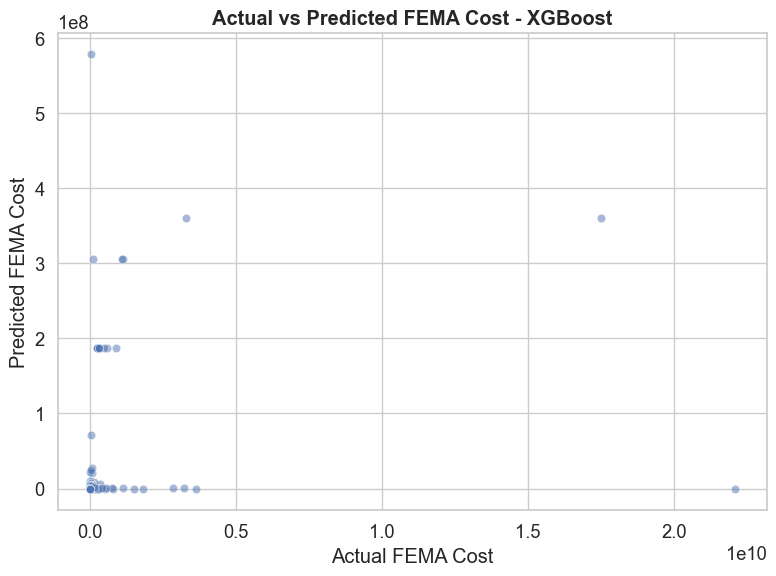

Best model: XGBoost


In [90]:

best_name = results_df.index[0]
best_model = trained_models[best_name]

preds_log = best_model.predict(X_test)

actual = np.expm1(y_test)
predicted = np.expm1(preds_log)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=actual,
    y=predicted,
    alpha=0.5
)

plt.xlabel("Actual FEMA Cost")
plt.ylabel("Predicted FEMA Cost")
plt.title(f"Actual vs Predicted FEMA Cost - {best_name}", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Best model: {best_name}")

STEP 9 - Save Best Model

In [91]:

joblib.dump(
    best_model,
    os.path.join(MODEL_DIR, "fema_cost_model.pkl")
)

print(f"Best model saved: {best_name}")
print("Saved to:", os.path.join(MODEL_DIR, "fema_cost_model.pkl"))

Best model saved: XGBoost
Saved to: ..\models\fema_cost_model.pkl
